In [107]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [6]:
x = torch.randperm(1100)
x


tensor([ 78, 392, 452,  ..., 867, 585,  32])

In [111]:
### Here, we visualize batch norm shifting all activations back to a stdNorm ###

In [112]:
input = torch.tensor(np.random.rand(32,10), dtype=torch.float32).unsqueeze(2)
input.shape

torch.Size([32, 10, 1])

In [136]:
out_channels = 2
conv = nn.Conv1d(10, out_channels, 3, stride=1, padding='same')
out = conv(input)
out[:3]

tensor([[[-0.1733],
         [-0.1578]],

        [[-0.3229],
         [-0.0547]],

        [[-0.2680],
         [-0.1822]]], grad_fn=<SliceBackward0>)

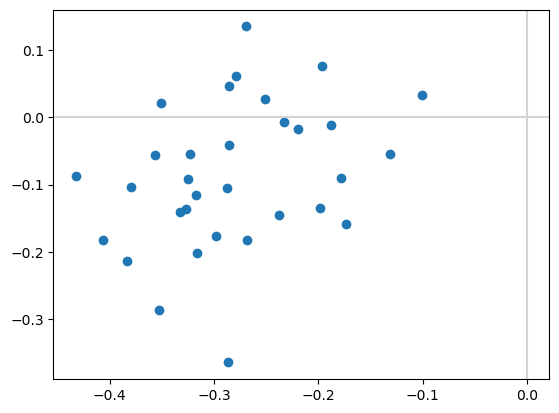

In [137]:
x, y = [], []
for a, b in out.squeeze(2):
    x.append(a.item())
    y.append(b.item())

fig, ax = plt.subplots()
ax.scatter(x, y)
plt.axhline(0, color='lightgray')
plt.axvline(0, color='lightgray')



In [138]:
out2 = nn.BatchNorm1d(out_channels)(out)
print(out2[:3])


tensor([[[ 1.3680],
         [-0.6707]],

        [[-0.5481],
         [ 0.2935]],

        [[ 0.1559],
         [-0.8991]]], grad_fn=<SliceBackward0>)


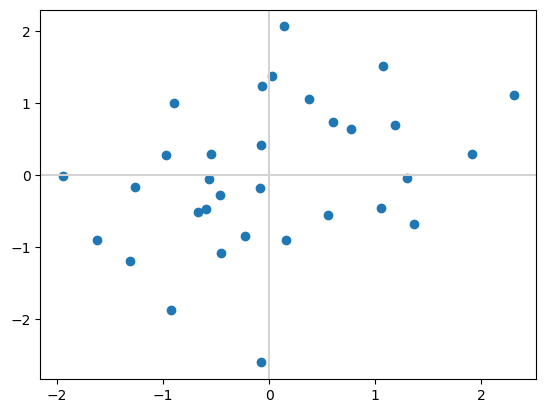

In [139]:
x, y = [], []
for a, b in out2.squeeze(2):
    x.append(a.item())
    y.append(b.item())

fig, ax = plt.subplots()
ax.scatter(x, y)
plt.axhline(0, color='lightgray')
plt.axvline(0, color='lightgray')



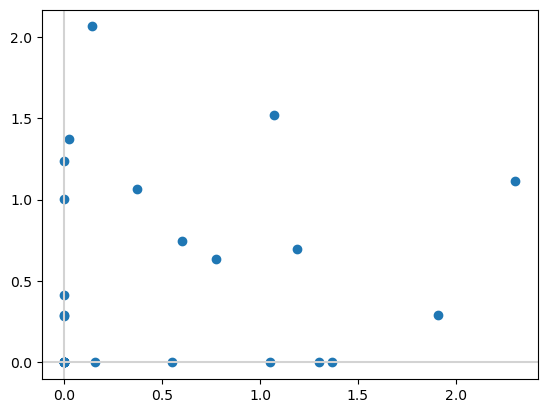

In [141]:
out3 = nn.ReLU()(out2)
x, y = [], []
for a, b in out3.squeeze(2):
    x.append(a.item())
    y.append(b.item())

fig, ax = plt.subplots()
ax.scatter(x, y)
plt.axhline(0, color='lightgray')
plt.axvline(0, color='lightgray')


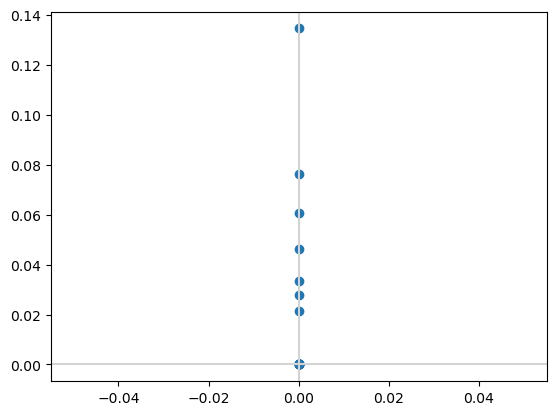

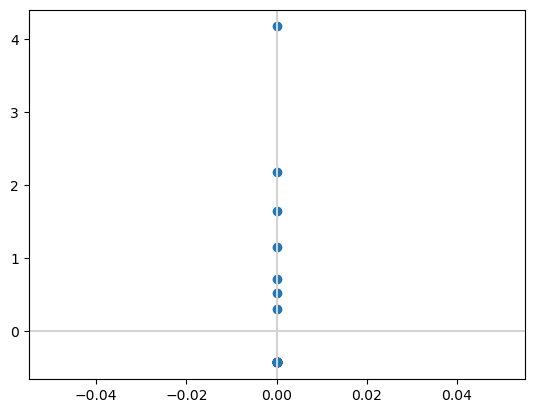

In [147]:
out2_2 = nn.ReLU()(out)
out3_2 = nn.BatchNorm1d(out_channels)(out2_2)


x, y = [], []
for a, b in out2_2.squeeze(2):
    x.append(a.item())
    y.append(b.item())

fig, ax = plt.subplots()
ax.scatter(x, y)
plt.axhline(0, color='lightgray')
plt.axvline(0, color='lightgray')



x, y = [], []
for a, b in out3_2.squeeze(2):
    x.append(a.item())
    y.append(b.item())

fig, ax = plt.subplots()
ax.scatter(x, y)
plt.axhline(0, color='lightgray')
plt.axvline(0, color='lightgray')


In [ ]:
### playing with pooling ###


In [221]:
# batch = 32, channel = 1, features = 10
input = torch.tensor(np.random.rand(32, 10), dtype=torch.float32).unsqueeze(1)
input.shape


torch.Size([32, 1, 10])

In [222]:
input[:2]

tensor([[[0.7564, 0.1013, 0.8613, 0.0660, 0.9325, 0.4169, 0.4425, 0.7993,
          0.8090, 0.5933]],

        [[0.0682, 0.7211, 0.1897, 0.9616, 0.6135, 0.6449, 0.9063, 0.0813,
          0.9162, 0.4045]]])

In [240]:
feature_maps = 5
conv_out = nn.Conv1d(1, feature_maps, 3, stride=1, padding='same')(input)
print(conv_out.shape)
conv_out[:2]


torch.Size([32, 5, 10])


tensor([[[-0.3400,  0.3898, -0.3715,  0.4546, -0.3633,  0.2015,  0.0830,
          -0.1042, -0.0321, -0.0093],
         [ 0.3487, -0.0255,  0.4038, -0.0494,  0.2661,  0.2553,  0.0346,
           0.1206,  0.2666,  0.4692],
         [ 0.2996,  0.4672,  0.3538,  0.5005,  0.4211,  0.5403,  0.4512,
           0.5612,  0.6357,  0.4801],
         [-0.3456, -0.2879, -0.3012, -0.2690, -0.2750, -0.1987, -0.2889,
          -0.2019, -0.1316, -0.2086],
         [ 0.3692,  0.5280,  0.4233,  0.5588,  0.3691,  0.6790,  0.4243,
           0.4615,  0.6359,  0.6997]],

        [[ 0.1437, -0.2840,  0.3465, -0.3070,  0.1362,  0.0518, -0.2207,
           0.4577, -0.3515,  0.1290],
         [-0.0828,  0.3122, -0.0521,  0.2070,  0.2206,  0.0663,  0.4866,
          -0.0322,  0.2696,  0.4389],
         [ 0.2073,  0.3247,  0.4980,  0.4988,  0.6378,  0.5850,  0.5325,
           0.5156,  0.4190,  0.4591],
         [-0.4700, -0.3340, -0.2705, -0.2310, -0.1374, -0.1940, -0.1699,
          -0.2564, -0.2760, -0.2277],

In [241]:
# (B, C, N), pools on N, returns (B, C, 1)
pool_out = nn.AdaptiveAvgPool1d(1)(conv_out)
pool_out.shape, pool_out[:2]


(torch.Size([32, 5, 1]),
 tensor([[[-0.0091],
          [ 0.2090],
          [ 0.4711],
          [-0.2508],
          [ 0.5149]],
 
         [[ 0.0102],
          [ 0.1834],
          [ 0.4678],
          [-0.2567],
          [ 0.5040]]], grad_fn=<SliceBackward0>))

In [248]:
flat_out = torch.flatten(pool_out, 1) # flatten all dimensions except batch
flat_out.shape

torch.Size([32, 5])

In [279]:
flat_out

tensor([[-9.1494e-03,  2.0899e-01,  4.7106e-01, -2.5085e-01,  5.1487e-01],
        [ 1.0180e-02,  1.8342e-01,  4.6780e-01, -2.5669e-01,  5.0398e-01],
        [ 2.4242e-02,  2.0373e-01,  3.3738e-01, -3.4193e-01,  4.5190e-01],
        [ 2.0801e-02,  2.0823e-01,  3.7144e-01, -3.1831e-01,  4.7238e-01],
        [ 3.1249e-02,  1.9552e-01,  3.1206e-01, -3.6019e-01,  4.3529e-01],
        [-1.9525e-03,  2.1630e-01,  4.2063e-01, -2.8389e-01,  4.9514e-01],
        [ 2.9611e-02,  2.0011e-01,  3.6596e-01, -3.2317e-01,  4.6764e-01],
        [-5.0315e-03,  1.8646e-01,  4.0122e-01, -3.0112e-01,  4.6237e-01],
        [ 1.3347e-04,  1.9250e-01,  4.2636e-01, -2.8334e-01,  4.8279e-01],
        [-1.8058e-02,  2.1422e-01,  5.2593e-01, -2.1306e-01,  5.4496e-01],
        [ 8.1153e-03,  2.0486e-01,  3.9799e-01, -3.0080e-01,  4.7914e-01],
        [ 9.5271e-03,  1.8841e-01,  3.5768e-01, -3.3029e-01,  4.4603e-01],
        [-1.1778e-03,  2.2252e-01,  4.4110e-01, -2.6923e-01,  5.1114e-01],
        [-4.9743e-03,  1.

In [242]:
lin_out = nn.Linear(feature_maps, 11)(flat_out)
lin_out.shape


torch.Size([32, 11])

In [243]:
lin_out

tensor([[ 4.2942e-01, -4.3263e-01, -7.3504e-01,  2.6965e-02,  1.0416e-01,
          1.5845e-01, -5.5583e-01, -1.6173e-01,  2.2393e-03,  7.8335e-02,
          1.8518e-01],
        [ 4.2649e-01, -4.3888e-01, -7.3813e-01,  2.0757e-02,  1.0879e-01,
          1.5851e-01, -5.4979e-01, -1.6061e-01,  5.4660e-03,  7.8333e-02,
          1.9534e-01],
        [ 3.7512e-01, -3.9206e-01, -6.8660e-01, -2.6166e-02,  8.1725e-02,
          1.7935e-01, -4.6937e-01, -2.0933e-01,  1.3922e-02,  6.7908e-02,
          1.6512e-01],
        [ 3.8916e-01, -4.0510e-01, -7.0082e-01, -1.3689e-02,  8.8754e-02,
          1.7589e-01, -4.8858e-01, -1.9691e-01,  1.2568e-02,  7.1990e-02,
          1.7077e-01],
        [ 3.6437e-01, -3.8420e-01, -6.7715e-01, -3.6586e-02,  7.7732e-02,
          1.8206e-01, -4.5393e-01, -2.1805e-01,  1.5737e-02,  6.5103e-02,
          1.6319e-01],
        [ 4.0953e-01, -4.1535e-01, -7.1566e-01,  8.4071e-03,  9.4166e-02,
          1.6684e-01, -5.2404e-01, -1.8042e-01,  5.9396e-03,  7.4579e-0

In [274]:
# resnet model 
# when tuning start with learning rate->mini_batch_size -> 
# momentum-> #hidden_units -> # learning_rate_decay -> #layers 
import numpy as np
import time
import keras
import tensorflow as tf

import matplotlib
from utils.utils import save_test_duration

matplotlib.use('agg')
import matplotlib.pyplot as plt

from utils.utils import save_logs
from utils.utils import calculate_metrics


class Classifier_RESNET:
    def __init__(self, output_directory, input_shape, nb_classes, verbose=False, build=True, load_weights=False):
        self.output_directory = output_directory
        if build == True:
            self.model = self.build_model(input_shape, nb_classes)
            if (verbose == True):
                self.model.summary()
            self.verbose = verbose
            if load_weights == True:
                self.model.load_weights(self.output_directory
                                        .replace('resnet_augment', 'resnet')
                                        .replace('TSC_itr_augment_x_10', 'TSC_itr_10')
                                        + '/model_init.weights.h5')
            else:
                self.model.save_weights(self.output_directory + 'model_init.weights.h5')
        return

    def build_model(self, input_shape, nb_classes):
        n_feature_maps = 64

        input_layer = keras.layers.Input(input_shape)

        # BLOCK 1

        conv_x = keras.layers.Conv1D(filters=n_feature_maps, kernel_size=8, padding='same')(input_layer)
        conv_x = keras.layers.BatchNormalization()(conv_x)
        conv_x = keras.layers.Activation('relu')(conv_x)

        conv_y = keras.layers.Conv1D(filters=n_feature_maps, kernel_size=5, padding='same')(conv_x)
        conv_y = keras.layers.BatchNormalization()(conv_y)
        conv_y = keras.layers.Activation('relu')(conv_y)

        conv_z = keras.layers.Conv1D(filters=n_feature_maps, kernel_size=3, padding='same')(conv_y)
        conv_z = keras.layers.BatchNormalization()(conv_z)

        # expand channels for the sum
        shortcut_y = keras.layers.Conv1D(filters=n_feature_maps, kernel_size=1, padding='same')(input_layer)
        shortcut_y = keras.layers.BatchNormalization()(shortcut_y)

        output_block_1 = keras.layers.add([shortcut_y, conv_z])
        output_block_1 = keras.layers.Activation('relu')(output_block_1)

        # BLOCK 2

        conv_x = keras.layers.Conv1D(filters=n_feature_maps * 2, kernel_size=8, padding='same')(output_block_1)
        conv_x = keras.layers.BatchNormalization()(conv_x)
        conv_x = keras.layers.Activation('relu')(conv_x)

        conv_y = keras.layers.Conv1D(filters=n_feature_maps * 2, kernel_size=5, padding='same')(conv_x)
        conv_y = keras.layers.BatchNormalization()(conv_y)
        conv_y = keras.layers.Activation('relu')(conv_y)

        conv_z = keras.layers.Conv1D(filters=n_feature_maps * 2, kernel_size=3, padding='same')(conv_y)
        conv_z = keras.layers.BatchNormalization()(conv_z)

        # expand channels for the sum
        shortcut_y = keras.layers.Conv1D(filters=n_feature_maps * 2, kernel_size=1, padding='same')(output_block_1)
        shortcut_y = keras.layers.BatchNormalization()(shortcut_y)

        output_block_2 = keras.layers.add([shortcut_y, conv_z])
        output_block_2 = keras.layers.Activation('relu')(output_block_2)

        # BLOCK 3

        conv_x = keras.layers.Conv1D(filters=n_feature_maps * 2, kernel_size=8, padding='same')(output_block_2)
        conv_x = keras.layers.BatchNormalization()(conv_x)
        conv_x = keras.layers.Activation('relu')(conv_x)

        conv_y = keras.layers.Conv1D(filters=n_feature_maps * 2, kernel_size=5, padding='same')(conv_x)
        conv_y = keras.layers.BatchNormalization()(conv_y)
        conv_y = keras.layers.Activation('relu')(conv_y)

        conv_z = keras.layers.Conv1D(filters=n_feature_maps * 2, kernel_size=3, padding='same')(conv_y)
        conv_z = keras.layers.BatchNormalization()(conv_z)

        # no need to expand channels because they are equal
        shortcut_y = keras.layers.BatchNormalization()(output_block_2)

        output_block_3 = keras.layers.add([shortcut_y, conv_z])
        output_block_3 = keras.layers.Activation('relu')(output_block_3)

        # FINAL

        gap_layer = keras.layers.GlobalAveragePooling1D()(output_block_3)

        output_layer = keras.layers.Dense(nb_classes, activation='softmax')(gap_layer)

        model = keras.models.Model(inputs=input_layer, outputs=output_layer)

        model.compile(loss='categorical_crossentropy', optimizer=keras.optimizers.Adam(),
                      metrics=['accuracy'])

        file_path = self.output_directory + 'best_model.keras'

        reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=50, min_lr=0.0001)
        model_checkpoint = keras.callbacks.ModelCheckpoint(filepath=file_path, monitor='loss',
                                                           save_best_only=True)

        self.callbacks = [reduce_lr, model_checkpoint]

        return model

    def fit(self, x_train, y_train, x_val, y_val, y_true):
        if not tf.test.is_gpu_available:
            print('error')
            exit()
        # x_val and y_val are only used to monitor the test loss and NOT for training
        batch_size = 64
        nb_epochs = 1500

        mini_batch_size = int(min(x_train.shape[0] / 10, batch_size))

        start_time = time.time()

        hist = self.model.fit(x_train, y_train, batch_size=mini_batch_size, epochs=nb_epochs,
                              verbose=self.verbose, validation_data=(x_val, y_val), callbacks=self.callbacks)

        duration = time.time() - start_time

        self.model.save(self.output_directory + 'last_model.weights.h5')

        y_pred = self.predict(x_val, y_true, x_train, y_train, y_val,
                              return_df_metrics=False)

        # save predictions
        np.save(self.output_directory + 'y_pred.npy', y_pred)

        # convert the predicted from binary to integer
        y_pred = np.argmax(y_pred, axis=1)

        df_metrics = save_logs(self.output_directory, hist, y_pred, y_true, duration)

        keras.backend.clear_session()

        return df_metrics

    def predict(self, x_test, y_true, x_train, y_train, y_test, return_df_metrics=True):
        start_time = time.time()
        model_path = self.output_directory + 'best_model.keras'
        model = keras.models.load_model(model_path)
        y_pred = model.predict(x_test)
        if return_df_metrics:
            y_pred = np.argmax(y_pred, axis=1)
            df_metrics = calculate_metrics(y_true, y_pred, 0.0)
            return df_metrics
        else:
            test_duration = time.time() - start_time
            save_test_duration(self.output_directory + 'test_duration.csv', test_duration)
            return y_pred



In [275]:
# config variables
archive_name = 'custom'
dataset_name = 'h265'
classifier_name = 'resnet_pytorch'
itr = '_itr_5'

root_dir = "/mnt/hbnas/home/fgan/Proj-Entropy/Video_Classification_Model/dl-4-tsc"

print('Method: ', archive_name, dataset_name, classifier_name, itr)

output_directory = root_dir + '/results/' + classifier_name + '/' + archive_name + itr + '/' + \
                    dataset_name + '/'
print(output_directory)


Method:  custom h265 resnet_pytorch _itr_5
/mnt/hbnas/home/fgan/Proj-Entropy/Video_Classification_Model/dl-4-tsc/results/resnet_pytorch/custom_itr_5/h265/


In [277]:
def create_classifier(classifier_name, input_shape, nb_classes, output_directory, verbose=True):
    if classifier_name == 'resnet_pytorch':
        return Classifier_RESNET(output_directory, input_shape, nb_classes, verbose)

input_shape = (3000, 1)
nb_classes = 11
classifier = create_classifier(classifier_name, input_shape, nb_classes, output_directory)
# classifier.model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 3000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_99 (Conv1D)  │ (None, 3000, 64)  │        576 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 64)  │        256 │ conv1d_99[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_81       │ (None, 3000, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_100 (Conv1D) │ (None, 3000, 64)  │     20,544 │ activation_81[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 64)  │        256 │ conv1d_100[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_82       │ (None, 3000, 64)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_102 (Conv1D) │ (None, 3000, 64)  │        128 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_101 (Conv1D) │ (None, 3000, 64)  │     12,352 │ activation_82[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 64)  │        256 │ conv1d_102[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 64)  │        256 │ conv1d_101[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_27 (Add)        │ (None, 3000, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_83       │ (None, 3000, 64)  │          0 │ add_27[0][0]      │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_103 (Conv1D) │ (None, 3000, 128) │     65,664 │ activation_83[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 128) │        512 │ conv1d_103[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_84       │ (None, 3000, 128) │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_104 (Conv1D) │ (None, 3000, 128) │     82,048 │ activation_84[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 3000, 128) │        512 │ conv1d_104[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_85       │ (None, 3000, 128) │          0 │ batch_normalizat

 Total params: 507,979 (1.94 MB)

 Trainable params: 505,419 (1.93 MB)

 Non-trainable params: 2,560 (10.00 KB)